In [2]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 2.2  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -0.74640135 Ha
FCI能量: -0.94122403 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [7]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=False, sweep_size=64
)

In [4]:
hi.all_states()

Array([[0, 1, 0, 1],
       [0, 1, 1, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0]], dtype=int8)

In [5]:
import jax
import jax.numpy as jnp
from flax import nnx
class ComplexFFN(nnx.Module):
    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)
    
    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.complex(nnx.relu(y.real), nnx.relu(y.imag))  # 添加复数部分
        return jnp.sum(y, axis=-1)


In [6]:
N = 4
ffnn_model = ComplexFFN(N=N, alpha=1, rngs=nnx.Rngs(2))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_ffnn"

AttributeError: module 'flax.nnx' has no attribute 'complex'

In [13]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:02<00:00, 103.38it/s, Energy=-0.74533 ± 0.00041 [σ²=0.00008, R̂=1.0234]]


(JsonLog('h2_molecule_ffnn', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.01483917236328125
   	Params: 0.014266729354858398,)

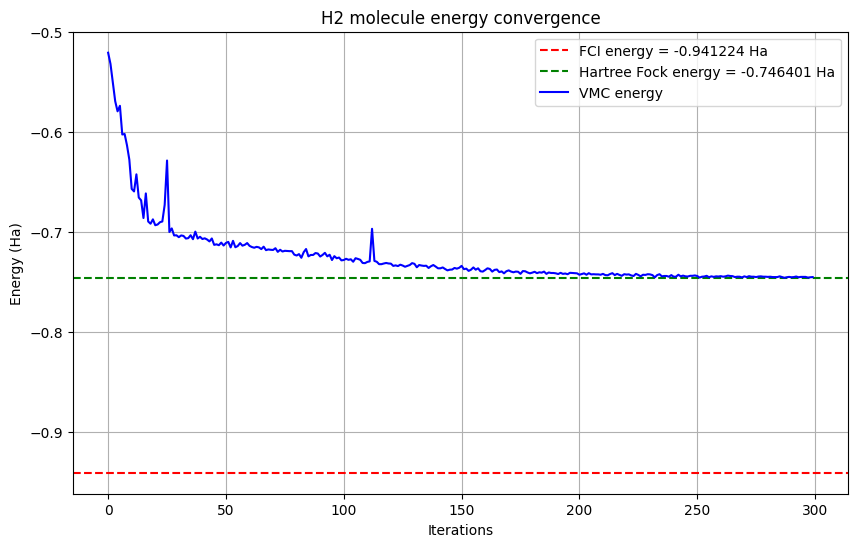


最终VMC能量: -0.74532769 Ha
与FCI能量误差: 0.19589635 Ha


In [18]:
############## 绘图 #################
exp_name = "h2_molecule_ffnn"
# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")


In [15]:
# 假设 vs 是你已经训练好的 MCState
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成大量样本以获得准确的概率分布
n_samples = 10000  # 增加样本数量以获得更准确的概率
samples = vs.sample(n_samples=n_samples)

# 2. 将样本重塑为二维数组 (n_samples, n_orbitals)
samples_flat = samples.reshape(-1, samples.shape[-1])

# 3. 统计每个组态的出现次数
unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)

# 4. 计算概率
probabilities = counts / np.sum(counts)

# 5. 按概率排序
sorted_indices = np.argsort(probabilities)[::-1]
sorted_configs = unique_configs[sorted_indices]
sorted_probs = probabilities[sorted_indices]

print("组态及其概率分布:")
print("组态(轨道占据)    概率      物理解释")
print("-" * 50)
for i, (config, prob) in enumerate(zip(sorted_configs[:10], sorted_probs[:10])):  # 显示前10个主要组态
    # 解释组态的物理意义
    occupied_orbitals = np.where(config == 1)[0]
    print(f"{config}         {prob:.6f}   电子占据轨道: {occupied_orbitals}")


组态及其概率分布:
组态(轨道占据)    概率      物理解释
--------------------------------------------------
[1 0 1 0]         0.991100   电子占据轨道: [0 2]
[0 1 1 0]         0.008900   电子占据轨道: [1 2]


In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def interactive_visualization(vs, ha, E_fci):
    """创建交互式可视化"""
    
    # 生成数据
    samples = vs.sample(n_samples=5000)
    samples_flat = samples.reshape(-1, samples.shape[-1])
    unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)
    probabilities = counts / np.sum(counts)
    
    sorted_indices = np.argsort(probabilities)[::-1]
    sorted_configs = unique_configs[sorted_indices]
    sorted_probs = probabilities[sorted_indices]
    
    # 创建子图
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('组态概率分布', '能量对比', '轨道占据热图', '概率累积'),
        specs=[[{"type": "bar"}, {"type": "bar"}],
               [{"type": "heatmap"}, {"type": "scatter"}]]
    )
    
    # 1. 柱状图
    n_configs = min(15, len(sorted_configs))
    config_labels = [f"{config}" for config in sorted_configs[:n_configs]]
    
    fig.add_trace(
        go.Bar(x=config_labels, y=sorted_probs[:n_configs],
               marker_color='lightblue'),
        row=1, col=1
    )
    
    # 2. 能量对比
    fig.add_trace(
        go.Bar(x=['FCI', 'VMC', 'HF'], 
               y=[E_fci, vs.energy.mean, -1.11675931],
               marker_color=['red', 'blue', 'green']),
        row=1, col=2
    )
    
    # 3. 热图
    fig.add_trace(
        go.Heatmap(z=sorted_configs[:20],
                   colorscale='RdBu',
                   showscale=True),
        row=2, col=1
    )
    
    # 4. 累积概率
    cumulative_probs = np.cumsum(sorted_probs)
    fig.add_trace(
        go.Scatter(x=list(range(len(cumulative_probs))), 
                   y=cumulative_probs,
                   mode='lines'),
        row=2, col=2
    )
    
    fig.update_layout(height=800, showlegend=False,
                     title_text="H₂分子VMC计算交互式分析")
    
    fig.show()

# 调用交互式可视化
interactive_visualization(vs, ha, E_fci)


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/utils/timing.py:276: UserWarning:

n_samples=5000 (5000 per device/MPI rank) does not divide n_chains=16, increased to 5008 (5008 per device/MPI rank)



AttributeError: 'MCState' object has no attribute 'energy'